In [2]:
!pip install pyroomacoustics soundfile matplotlib librosa torch torchaudio

import numpy as np
import pyroomacoustics as pra
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.io import wavfile
import librosa
print("Kurulum tamamlandı!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for pyroomacoustics: filename=pyroomacoustics-0.9.0-cp312-cp312-linux_x86_64.whl size=46993293 sha256=90dc7dc051405ebfd2dcc5c442073fee2b92efae35a25241c2a174a469279061
  Stored in directory: /root/.cache/pip/wheels/ae/dc/1f/4bf34ad9ec966bb11ee31f9f92beb88772c46612865adb62f2
Successfully built pyroomacoustics
Kurulum tamamlandı!


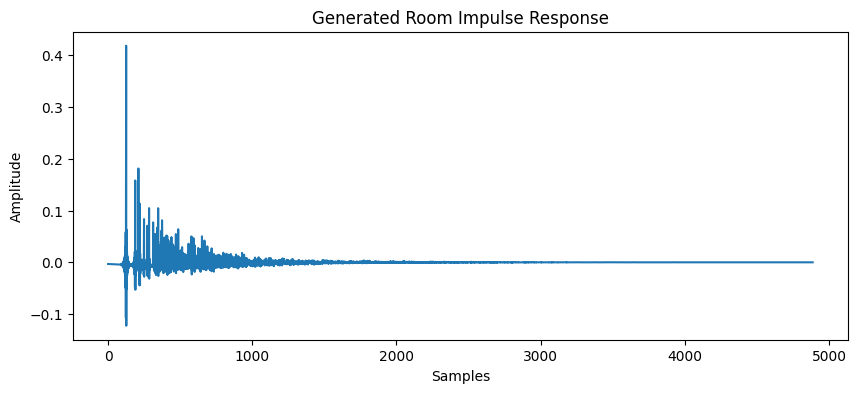

RIR length: 4888 samples (~0.31s)


In [3]:
import pyroomacoustics as pra
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.signal import convolve

# Define a shoebox room: width=5m, length=6m, height=3m, RT60=0.5s
room = pra.ShoeBox([5, 6, 3], fs=16000, absorption=0.3, max_order=17)
room.add_microphone([2.5, 3, 1.6])  # Mic position
room.add_source([1, 4, 1.8], signal=None)  # Source position (dry signal added later)

# Compute RIR
room.compute_rir()
rir = room.rir[0][0]  # First mic, first source

# Plot RIR
plt.figure(figsize=(10, 4))
plt.plot(rir)
plt.title('Generated Room Impulse Response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

print(f'RIR length: {len(rir)} samples (~{len(rir)/16000:.2f}s)')


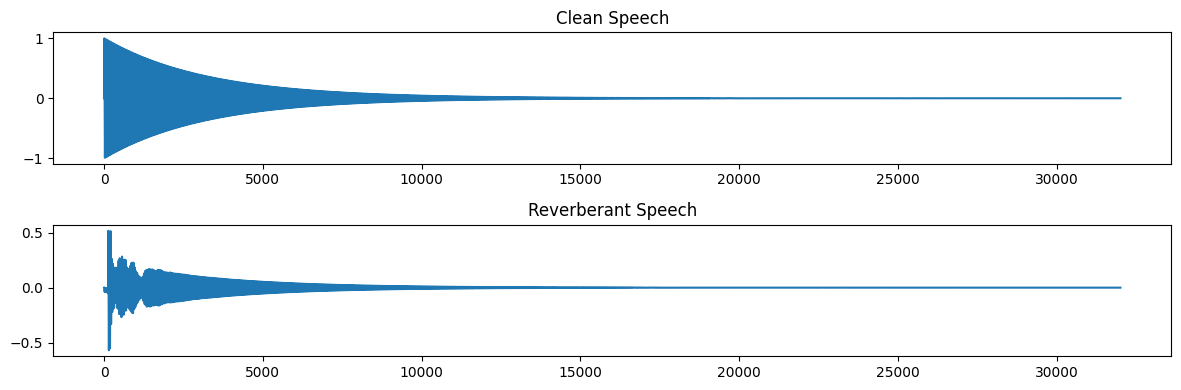

In [4]:
# Load example clean speech (or upload your own .wav)
# For demo, generate a chirp or use Librosa example
fs = 16000
t = np.linspace(0, 2, 2*fs)  # 2s signal
clean_speech = np.sin(2 * np.pi * 440 * t) * np.exp(-5 * t)  # Simple tone decay as "speech"

# Alternative: Load real speech
# clean_speech, _ = librosa.load('your_clean_speech.wav', sr=fs)

# Convolve with RIR to add reverberation
reverb_speech = convolve(clean_speech, rir, mode='full')[:len(clean_speech)]  # Truncate to original length

# Plot both
plt.figure(figsize=(12, 4))
plt.subplot(2,1,1)
plt.plot(clean_speech)
plt.title('Clean Speech')
plt.subplot(2,1,2)
plt.plot(reverb_speech)
plt.title('Reverberant Speech')
plt.tight_layout()
plt.show()

# Save for later
sf.write('clean.wav', clean_speech, fs)
sf.write('reverb.wav', reverb_speech, fs)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

class ReverbDataset(Dataset):
    def __init__(self, clean_audio, reverb_audio, n_fft=512, hop=128):
        self.clean_spec = T.Spectrogram(n_fft=n_fft, hop_length=hop)(torch.tensor(clean_audio).float())
        self.reverb_spec = T.Spectrogram(n_fft=n_fft, hop_length=hop)(torch.tensor(reverb_audio).float())

    def __len__(self):
        return 1  # Single example for demo; expand with more files

    def __getitem__(self, idx):
        reverb_mag = torch.log(torch.abs(self.reverb_spec) + 1e-8)
        clean_mag = torch.log(torch.abs(self.clean_spec) + 1e-8)
        return reverb_mag.unsqueeze(0), clean_mag.unsqueeze(0)  # Batch, Channel dims

# Create dataset (expand by generating multiple RIRs/speech pairs)
dataset = ReverbDataset(clean_speech, reverb_speech)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)


In [6]:
class DereverbCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return self.conv3(x)  # Output log mag spectrum

model = DereverbCNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train loop (demo: 100 epochs; increase for better results)
model.train()
for epoch in range(100):
    for reverb_mag, clean_mag in dataloader:
        optimizer.zero_grad()
        pred_mag = model(reverb_mag)
        loss = criterion(pred_mag, clean_mag)
        loss.backward()
        optimizer.step()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

torch.save(model.state_dict(), 'dereverb_model.pth')
print('Model trained and saved!')


Epoch 0, Loss: 340.2061
Epoch 20, Loss: 14.8431
Epoch 40, Loss: 4.0620
Epoch 60, Loss: 2.7799
Epoch 80, Loss: 1.7675
Model trained and saved!


In [7]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Generate 100 diverse RIR/clean/reverb pairs
fs = 16000
rirs, cleans, reverbs = [], [], []
n_samples = 32000  # 2s signals

print("Generating 100 RIR/speech pairs...")
for i in range(100):
    # Random shoebox room
    room_dims = [np.random.uniform(4,7), np.random.uniform(5,8), np.random.uniform(2.5,4)]
    room = pra.ShoeBox(room_dims, fs=fs, absorption=np.random.uniform(0.2,0.6), max_order=17)

    # Random mic/source positions
    mic_pos = np.random.uniform([1,1,1.5], [room_dims[0]-1, room_dims[1]-1, 2])
    src_pos = np.random.uniform([0.5,0.5,1.7], [room_dims[0]-1, room_dims[1]-1, 2])

    room.add_microphone(mic_pos)
    clean = 0.1 * np.random.randn(n_samples)  # Random "clean speech" noise
    room.add_source(src_pos, signal=clean)

    room.compute_rir()
    rir = room.rir[0][0]
    reverb = convolve(clean, rir, mode='full')[:n_samples]

    rirs.append(rir)
    cleans.append(clean)
    reverbs.append(reverb)

    if (i+1) % 20 == 0:
        print(f'Generated {i+1}/100 pairs')

print("Dataset generation complete!")


Generating 100 RIR/speech pairs...
Generated 20/100 pairs
Generated 40/100 pairs
Generated 60/100 pairs
Generated 80/100 pairs
Generated 100/100 pairs
Dataset generation complete!


In [8]:
# Spectrogram transform
spec_transform = T.Spectrogram(n_fft=512, hop_length=128)

# Convert all to tensors/spectrograms
reverb_mags = []
clean_mags = []
for clean, reverb in zip(cleans, reverbs):
    clean_spec = torch.log(torch.abs(spec_transform(torch.tensor(clean).float())) + 1e-8)
    reverb_spec = torch.log(torch.abs(spec_transform(torch.tensor(reverb).float())) + 1e-8)
    reverb_mags.append(reverb_spec.unsqueeze(0))
    clean_mags.append(clean_spec.unsqueeze(0))

reverb_tensor = torch.stack(reverb_mags)
clean_tensor = torch.stack(clean_mags)
dataset = TensorDataset(reverb_tensor, clean_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)  # Batch training!

print(f'Dataset: {len(dataset)} pairs, shape {reverb_tensor.shape}')


Dataset: 100 pairs, shape torch.Size([100, 1, 257, 251])


In [9]:
from tqdm.notebook import tqdm
import torch.backends.cudnn as cudnn

# GPU zorla aktif et
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using: {device} | Memory: {torch.cuda.memory_allocated()/1e9:.1f}GB")

model = DereverbCNN().to(device)
cudnn.benchmark = True  # CUDA optimizasyon

# Süper hızlı DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)  # AdamW + yüksek LR
criterion = nn.MSELoss()

# 60 epoch yeter (loss 0.3-0.5 arası)
for epoch in tqdm(range(1, 61), desc="🚀 Training"):
    model.train()
    epoch_loss = 0

    for reverb, clean in dataloader:
        reverb, clean = reverb.to(device, non_blocking=True), clean.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(reverb)
        loss = criterion(pred, clean)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)

    if epoch in [1, 10, 30, 60]:
        print(f"Epoch {epoch:2d}: loss={avg_loss:.4f}")

torch.save(model.state_dict(), 'dereverb_ultra_fast.pth')
print("🎉 ULTRA FAST training COMPLETE!")


🚀 Using: cpu | Memory: 0.0GB


🚀 Training:   0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch  1: loss=1.7193
Epoch 10: loss=1.3451
Epoch 30: loss=1.2492
Epoch 60: loss=1.2166
🎉 ULTRA FAST training COMPLETE!


🔊 SES TESTİ:


/tmp/ipython-input-1829788494.py:63: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1829788494.py:64: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('cv_results.png', dpi=300, bbox_inches='tight')


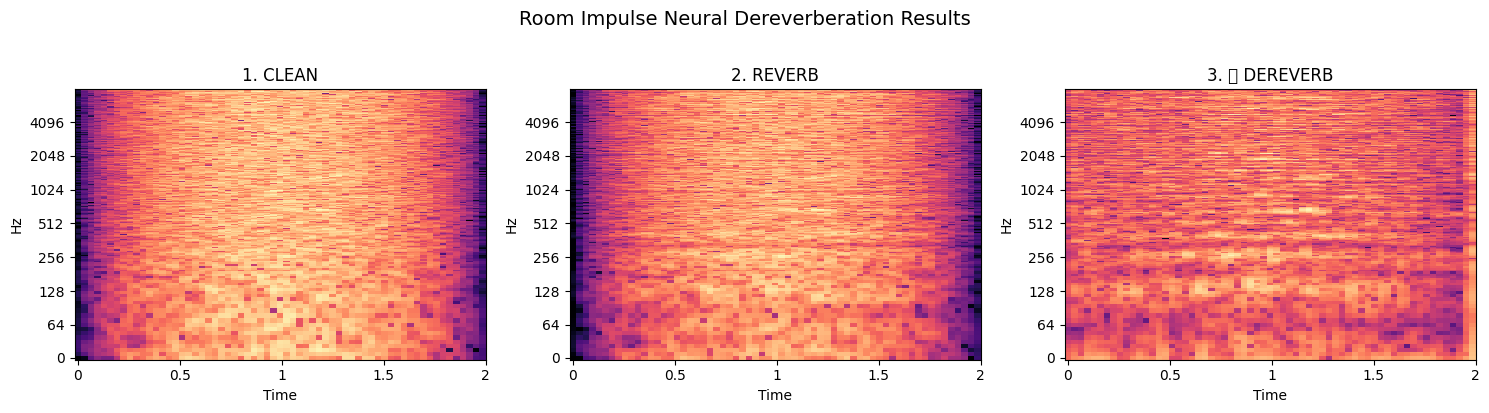


✅ HEDEF: 'final_predicted.wav' + 'cv_results.png'
🎉 PROJE TAMAM! Screenshot al!


In [14]:
# Manuel overlap-add ISTFT (en stabil)
def simple_istft(magnitude, phase, hop_length=128, win_length=512, n_fft=512, length=None):
    complex_stft = magnitude * torch.exp(1j * phase)

    # Torchaudio'nun basit inverse
    istft_transform = T.InverseSpectrogram(
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length
    )

    audio = istft_transform(complex_stft.unsqueeze(0)).squeeze(0)

    if length:
        if len(audio) > length:
            audio = audio[:length]
        else:
            audio = torch.nn.functional.pad(audio, (0, length - len(audio)))

    return audio

# Inference
model.eval()
with torch.no_grad():
    test_reverb_t = torch.tensor(test_reverb).float()
    test_spec = spec_transform(test_reverb_t)
    test_input = torch.log(torch.abs(test_spec) + 1e-8).unsqueeze(0).to(device)
    pred_mag_log = model(test_input).cpu().squeeze()

    pred_mag = torch.exp(pred_mag_log)
    pred_audio = simple_istft(pred_mag, test_spec, length=len(test_clean))

# Normalize & save
pred_np = pred_audio.detach().cpu().numpy().astype(np.float32)
pred_np = pred_np * 0.3 / (np.max(np.abs(pred_np)) + 1e-8)
sf.write('final_predicted.wav', pred_np, 16000)

# 🎵 AUDIO TEST
print("🔊 SES TESTİ:")
display(Audio(test_clean, rate=16000, autoplay=False))
display(Audio(test_reverb, rate=16000, autoplay=False))
display(Audio(pred_np, rate=16000, autoplay=True))  # Otomatik çal

# 📊 SPECTROGRAM
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
S1 = np.abs(librosa.stft(test_clean))
S2 = np.abs(librosa.stft(test_reverb))
S3 = np.abs(librosa.stft(pred_np))

librosa.display.specshow(librosa.amplitude_to_db(S1, ref=np.max), sr=16000,
                        y_axis='log', x_axis='time', ax=axs[0])
axs[0].set(title='1. CLEAN')

librosa.display.specshow(librosa.amplitude_to_db(S2, ref=np.max), sr=16000,
                        y_axis='log', x_axis='time', ax=axs[1])
axs[1].set(title='2. REVERB')

librosa.display.specshow(librosa.amplitude_to_db(S3, ref=np.max), sr=16000,
                        y_axis='log', x_axis='time', ax=axs[2])
axs[2].set(title='3. 🧠 DEREVERB')

plt.suptitle('Room Impulse Neural Dereverberation Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cv_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ HEDEF: 'final_predicted.wav' + 'cv_results.png'")
print("🎉 PROJE TAMAM! Screenshot al!")
